In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import hyperopt
from hyperopt import hp, fmin, tpe, Trials, partial
from hyperopt.early_stop import no_progress_loss
from lightgbm.callback import early_stopping
from sklearn.metrics import r2_score, mean_squared_error,explained_variance_score,mean_absolute_error
import pickle

In [21]:
data = pd.read_csv('micedata.csv',header = None)
data = data.values
# 分割输入和目标
X = data[:, 2:]  # 特征
y = data[:, :2]  # 预测目标
# 数据分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

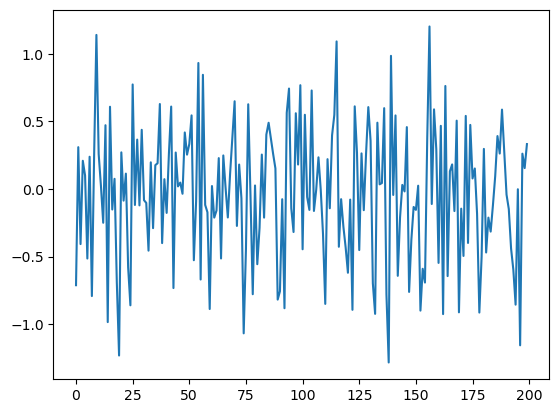

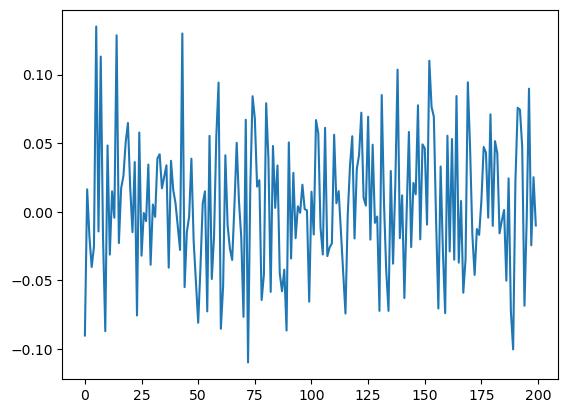

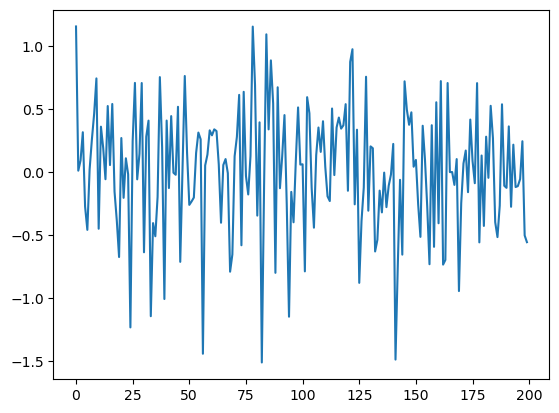

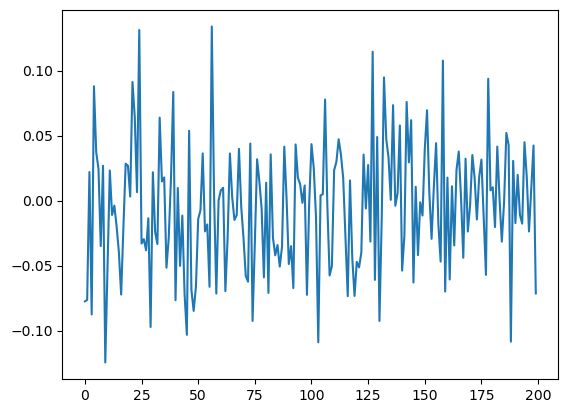

In [17]:
plt.plot(y_train[:,0][:200])
plt.show()
plt.plot(y_train[:,1][:200])
plt.show()
plt.plot(y_test[:,0][:200])
plt.show()
plt.plot(y_test[:,1][:200])
plt.show()

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

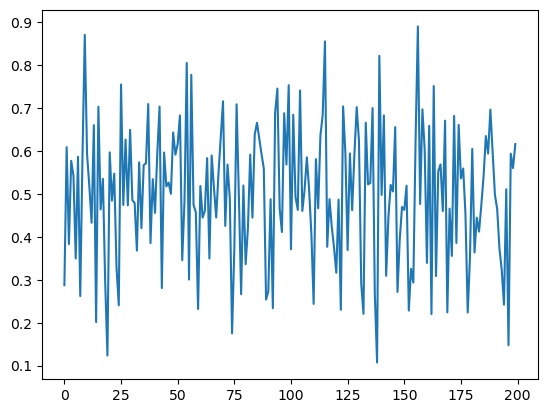

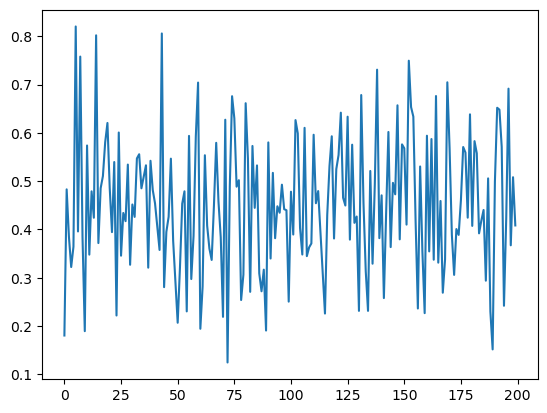

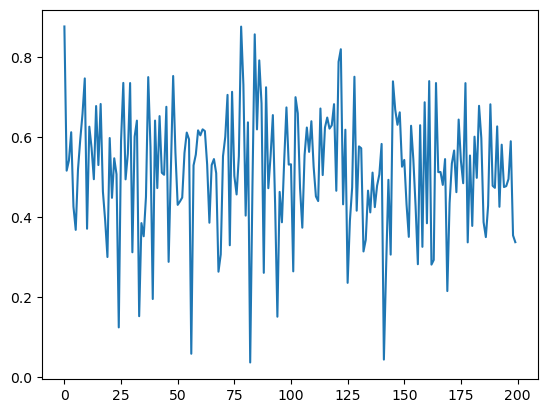

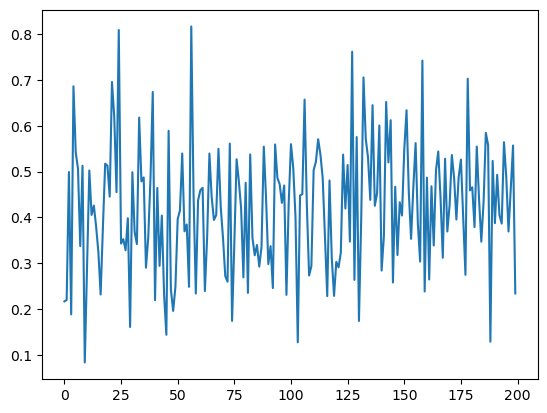

In [19]:
plt.plot(y_train[:,0][:200])
plt.show()
plt.plot(y_train[:,1][:200])
plt.show()
plt.plot(y_test[:,0][:200])
plt.show()
plt.plot(y_test[:,1][:200])
plt.show()

In [22]:
# 数据标准化
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

In [23]:

def train(params):
    print(params)
    model = lgb.LGBMRegressor(
        boosting_type='gbdt', # 提升类型，'gbdt' 表示传统的梯度提升决策树
        num_leaves=params['num_leaves'], # 树的叶子节点数量，较大的值可能导致更好的准确率，但也可能引起过拟合
        max_depth=params['max_depth'], # 树的最大深度，-1 表示没有限制
        learning_rate=params['learning_rate'], # 学习率，较小的值通常需要更多的树来训练
        n_estimators=100, # 提升树的数量，即训练过程中使用的树的数量
        objective='regression', # 训练目标，'regression' 表示回归任务
        subsample=params['subsample'], # 子样本的比例，用于防止过拟合
        colsample_bytree=params['colsample_bytree'], # 每次迭代中随机选择的特征比例
        reg_alpha=params['reg_alpha'], # L1 正则化项
        reg_lambda=0, # L2 正则化项
        random_state=1, # 随机数种子
        verbose = -1,
        min_data_in_leaf = 5
    )
    # 训练模型
    model.fit(X_train, 
              y_train1  ,        
              eval_set=[(X_test, y_test1)], # 验证数据集
              callbacks=[early_stopping(stopping_rounds=50)],)
    return model.best_score_['valid_0']['l2']  
param_grid_simple = {'num_leaves':hp.randint('num_leaves',30)+3
                     ,'max_depth':hp.randint('max_depth',17)+3
                     ,'learning_rate': hp.uniform("learning_rate",0.01,0.25)
                     # ,'min_child_samples':hp.randint('min_child_samples',25)+1
                     ,'subsample':hp.uniform("subsample",0.1,1)
                     ,'colsample_bytree': hp.uniform("colsample_bytree",0.1,1)
                    ,'reg_alpha': hp.uniform("reg_alpha",0.000001,0.1)
#                     ,'reg_lambda': hp.uniform("reg_lambda",0.000001,0.1)
                     ,'n_estimators': hp.randint('n_estimators',500)+50
                    }

def param_hyperopt(max_evals=100):
    
    #保存迭代过程
    trials = Trials()
    
    #设置提前停止
    early_stop_fn = no_progress_loss(100)
    
    #定义代理模型
    #algo = partial(tpe.suggest, n_startup_jobs=20, n_EI_candidates=50)
    params_best = fmin(train #目标函数
                       , space = param_grid_simple #参数空间
                       , algo = tpe.suggest 
                       #, algo = algo
                       , max_evals = max_evals #允许的迭代次数
                       , verbose=True
                       , trials = trials
                       , early_stop_fn = early_stop_fn
                      )
    
    #打印最优参数，fmin会自动打印最佳分数
    print("\n","\n","best params: ", params_best,
          "\n")
    return params_best, trials
params_list = []
for i in range(2):
    y_train1 = y_train[:,i]
    y_test1 = y_test[:,i]
    params_best, trials = param_hyperopt(max_evals=100)
    params_list.append(params_best)

{'colsample_bytree': 0.2538095776775802, 'learning_rate': 0.14310903723018742, 'max_depth': 3, 'n_estimators': 425, 'num_leaves': 32, 'reg_alpha': 0.03240921979556684, 'subsample': 0.10354764091452591}
Training until validation scores don't improve for 50 rounds                                                           
Did not meet early stopping. Best iteration is:                                                                        
[77]	valid_0's l2: 0.834868
{'colsample_bytree': 0.5143881701200442, 'learning_rate': 0.041123864696720684, 'max_depth': 16, 'n_estimators': 480, 'num_leaves': 24, 'reg_alpha': 0.024684915335898002, 'subsample': 0.48746990248599054}
Training until validation scores don't improve for 50 rounds                                                           
Did not meet early stopping. Best iteration is:                                                                        
[75]	valid_0's l2: 0.827932
{'colsample_bytree': 0.833744212306437, 'learning_rate': 

Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[18]	valid_0's l2: 0.850633
{'colsample_bytree': 0.2569988050591985, 'learning_rate': 0.08765160644637546, 'max_depth': 7, 'n_estimators': 478, 'num_leaves': 26, 'reg_alpha': 0.09003231022877754, 'subsample': 0.9919854231817964}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[45]	valid_0's l2: 0.856133
{'colsample_bytree': 0.33766112844174134, 'learning_rate': 0.23830988729943614, 'max_depth': 10, 'n_estimators': 146, 'num_leaves': 16, 'reg_alpha': 0.024696740939656417, 'subsample': 0.8318529763333268}
Training until validation scores don't improve for 50 round

Did not meet early stopping. Best iteration is:                                                                        
[100]	valid_0's l2: 0.868395
{'colsample_bytree': 0.7875667778557806, 'learning_rate': 0.11867344320218438, 'max_depth': 9, 'n_estimators': 193, 'num_leaves': 27, 'reg_alpha': 0.05066648702757869, 'subsample': 0.14272886285788894}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[18]	valid_0's l2: 0.852336
{'colsample_bytree': 0.9141075214850458, 'learning_rate': 0.18362617166078943, 'max_depth': 11, 'n_estimators': 177, 'num_leaves': 15, 'reg_alpha': 0.028132118871320222, 'subsample': 0.5567372168381808}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                        

{'colsample_bytree': 0.9420544905940408, 'learning_rate': 0.11698123790779592, 'max_depth': 3, 'n_estimators': 492, 'num_leaves': 3, 'reg_alpha': 0.06694878530278572, 'subsample': 0.15715083805552194}
Training until validation scores don't improve for 50 rounds                                                           
Did not meet early stopping. Best iteration is:                                                                        
[95]	valid_0's l2: 0.846941
{'colsample_bytree': 0.5776270148212873, 'learning_rate': 0.218133578639855, 'max_depth': 9, 'n_estimators': 339, 'num_leaves': 17, 'reg_alpha': 0.07610934531352191, 'subsample': 0.6671884878028693}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[11]	valid_0's l2: 0.886312
{'colsample_bytree': 0.7477365052452474, 'learning_rate': 0.1030

Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[19]	valid_0's l2: 0.866824
{'colsample_bytree': 0.4542689314203384, 'learning_rate': 0.059629248970459264, 'max_depth': 6, 'n_estimators': 179, 'num_leaves': 5, 'reg_alpha': 0.03444771039228023, 'subsample': 0.1998041160820278}
Training until validation scores don't improve for 50 rounds                                                           
Did not meet early stopping. Best iteration is:                                                                        
[99]	valid_0's l2: 0.843777
{'colsample_bytree': 0.3632240294162672, 'learning_rate': 0.11140575827548785, 'max_depth': 3, 'n_estimators': 297, 'num_leaves': 7, 'reg_alpha': 0.06767953361732491, 'subsample': 0.1175367628627555}
Training until validation scores don't improve for 50 rounds   

...

Early stopping, best iteration is:                                                                                     
[10]	valid_0's l2: 0.897938
{'colsample_bytree': 0.553345397852306, 'learning_rate': 0.1192967676649085, 'max_depth': 9, 'n_estimators': 192, 'num_leaves': 23, 'reg_alpha': 0.024505293388526517, 'subsample': 0.12372929070943806}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[5]	valid_0's l2: 0.901631
{'colsample_bytree': 0.613315100645814, 'learning_rate': 0.14679238312128687, 'max_depth': 5, 'n_estimators': 423, 'num_leaves': 20, 'reg_alpha': 0.010138063137516157, 'subsample': 0.5831839699578029}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                             

{'colsample_bytree': 0.5969195641862124, 'learning_rate': 0.13145575892554942, 'max_depth': 9, 'n_estimators': 171, 'num_leaves': 23, 'reg_alpha': 0.05563291123639422, 'subsample': 0.8989719460926153}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[18]	valid_0's l2: 0.900361
{'colsample_bytree': 0.6645061247181014, 'learning_rate': 0.028917866909028575, 'max_depth': 6, 'n_estimators': 520, 'num_leaves': 29, 'reg_alpha': 0.006089775262379325, 'subsample': 0.6181022566928656}
Training until validation scores don't improve for 50 rounds                                                           
Did not meet early stopping. Best iteration is:                                                                        
[72]	valid_0's l2: 0.880069
{'colsample_bytree': 0.25818881791333703, 'learning_rate': 0

Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[11]	valid_0's l2: 0.875591
{'colsample_bytree': 0.9373681706026973, 'learning_rate': 0.10897018322047884, 'max_depth': 7, 'n_estimators': 359, 'num_leaves': 10, 'reg_alpha': 0.07055960286974174, 'subsample': 0.4204390096134133}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[24]	valid_0's l2: 0.887749
{'colsample_bytree': 0.30804059713129106, 'learning_rate': 0.18141029201284065, 'max_depth': 11, 'n_estimators': 444, 'num_leaves': 18, 'reg_alpha': 0.07431776810920303, 'subsample': 0.3350792254542286}
Training until validation scores don't improve for 50 rounds

Early stopping, best iteration is:                                                                                     
[10]	valid_0's l2: 0.885288
{'colsample_bytree': 0.5527431784058119, 'learning_rate': 0.07748363656808939, 'max_depth': 3, 'n_estimators': 131, 'num_leaves': 11, 'reg_alpha': 0.07462335342168422, 'subsample': 0.55312769698497}
Training until validation scores don't improve for 50 rounds                                                           
Did not meet early stopping. Best iteration is:                                                                        
[54]	valid_0's l2: 0.890826
{'colsample_bytree': 0.1052565173686292, 'learning_rate': 0.051635580354713, 'max_depth': 15, 'n_estimators': 136, 'num_leaves': 12, 'reg_alpha': 0.07090242502736697, 'subsample': 0.6359408294135999}
Training until validation scores don't improve for 50 rounds                                                           
Did not meet early stopping. Best iteration is:                  

{'colsample_bytree': 0.2587887985191077, 'learning_rate': 0.2157464483118791, 'max_depth': 9, 'n_estimators': 85, 'num_leaves': 20, 'reg_alpha': 0.0723188763626425, 'subsample': 0.746248649336646}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[3]	valid_0's l2: 0.910188
{'colsample_bytree': 0.46956054481076404, 'learning_rate': 0.19882782951543282, 'max_depth': 8, 'n_estimators': 456, 'num_leaves': 16, 'reg_alpha': 0.08658392960720596, 'subsample': 0.8691461894047307}
Training until validation scores don't improve for 50 rounds                                                           
Early stopping, best iteration is:                                                                                     
[7]	valid_0's l2: 0.902874
{'colsample_bytree': 0.16323413903867182, 'learning_rate': 0.106536

In [25]:
n_es = [100,100]
for i in range(2):
    params = params_list[i]
    y_train1 = y_train[:,i]
    y_test1 = y_test[:,i]
    model = lgb.LGBMRegressor(
        boosting_type='gbdt', # 提升类型，'gbdt' 表示传统的梯度提升决策树
        num_leaves=params['num_leaves']+3, # 树的叶子节点数量，较大的值可能导致更好的准确率，但也可能引起过拟合
        max_depth=params['max_depth']+3, # 树的最大深度，-1 表示没有限制
        learning_rate=params['learning_rate'], # 学习率，较小的值通常需要更多的树来训练
        n_estimators=params['n_estimators'], # 提升树的数量，即训练过程中使用的树的数量
        objective='regression', # 训练目标，'regression' 表示回归任务
        subsample=params['subsample'], # 子样本的比例，用于防止过拟合
        colsample_bytree=params['colsample_bytree'], # 每次迭代中随机选择的特征比例
        reg_alpha=params['reg_alpha'], # L1 正则化项
        reg_lambda=0, # L2 正则化项
        random_state=1, # 随机数种子
        verbose = -1
    )
    # 训练模型
    model.fit(X_train, 
              y_train1  ,        
              eval_set=[(X_test, y_test1)], # 验证数据集
              callbacks=[early_stopping(stopping_rounds=10)],)
    #保存模型
    with open('lgbm_model_{}.pkl'.format(i), 'wb') as f:
        pickle.dump(model, f)

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[54]	valid_0's l2: 0.817082
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[14]	valid_0's l2: 0.881863


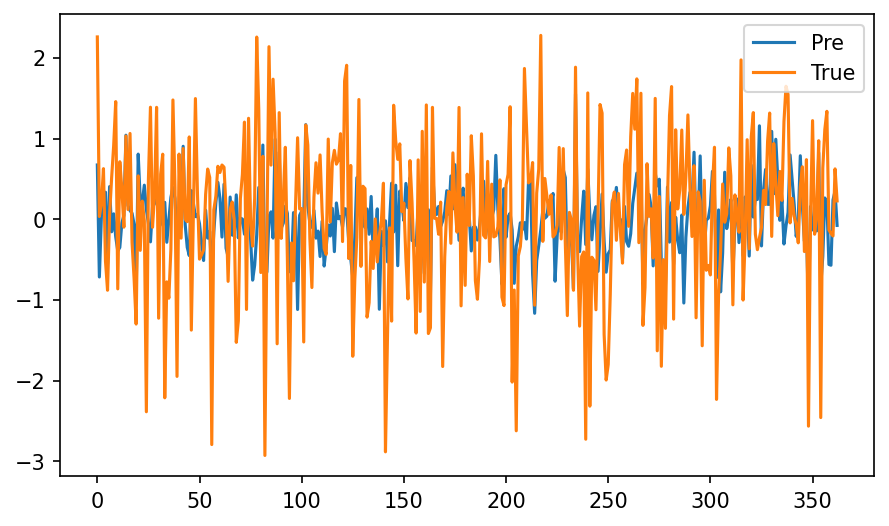

r2: 0.13374426230178693
ev: 0.13751290687717332
mse: 0.8170821433656075
rmse: 0.9039259612189526
mae: 0.7042971645483505
mape: 2.14062442134383


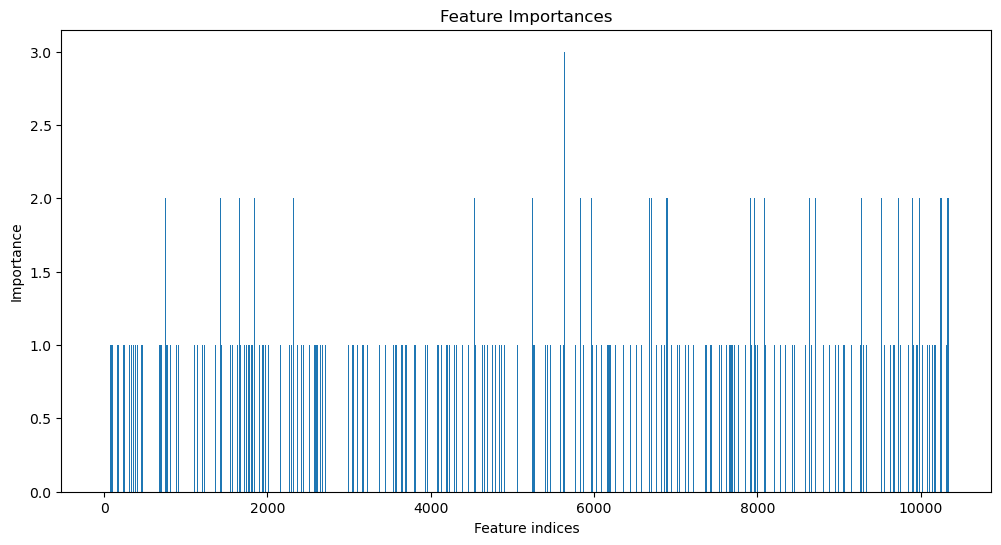

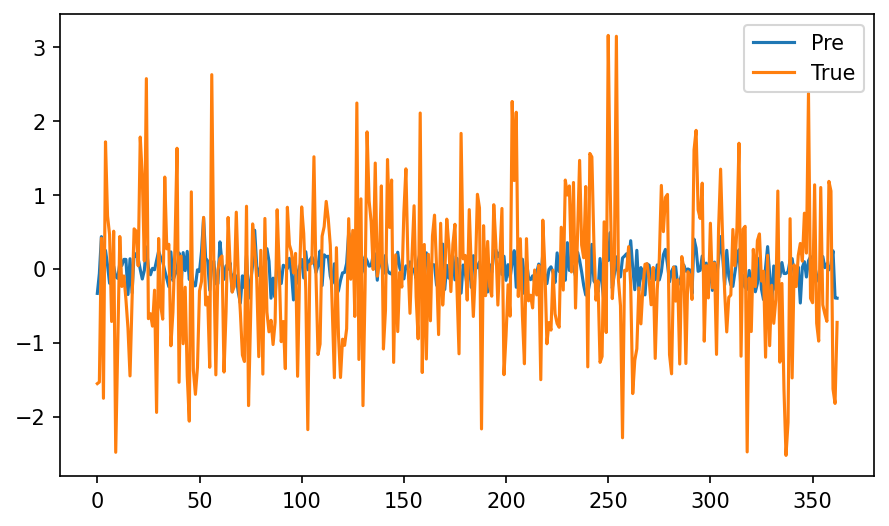

r2: 0.05717378739960677
ev: 0.064952043758576
mse: 0.8818631686842878
rmse: 0.9390756991234986
mae: 0.7319583807529092
mape: 1.5092622539297884


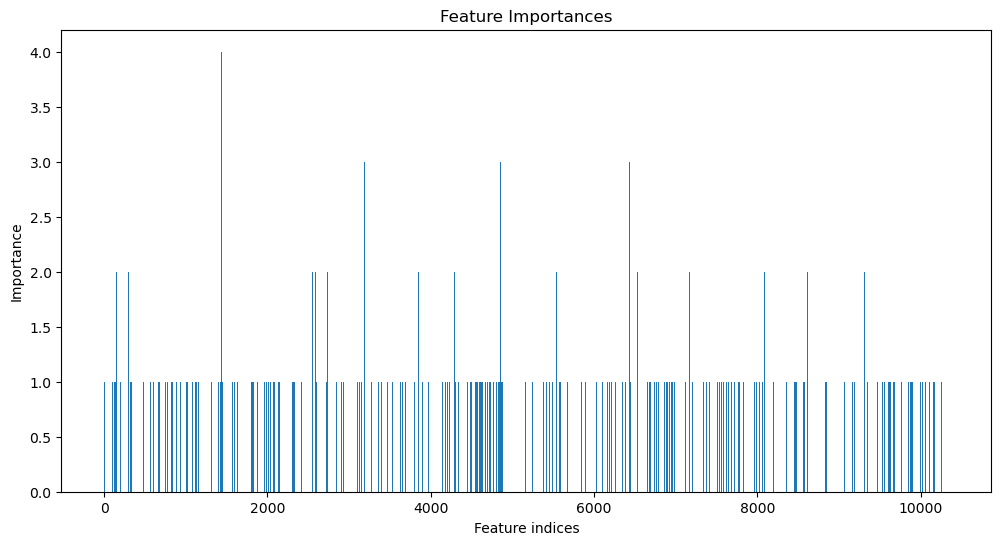

In [26]:
pred = []
for i in range(2):
    
    with open('lgbm_model_{}.pkl'.format(i), 'rb') as f:
        model = pickle.load(f)
    pre = model.predict(X_test)
    plt.figure(dpi=150,figsize=(7,4))
    plt.plot(pre.reshape(-1),label='Pre')
    plt.plot(y_test[:,i].reshape(-1),label = 'True')
    plt.legend()
    plt.show()
    Y_test1 = y_test[:,i]
    r2 = r2_score(Y_test1,pre)
    ev = explained_variance_score(Y_test1,pre)
    mse = mean_squared_error(Y_test1,pre)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test1,pre)

    pre = pre.reshape(-1)
    Y_test1 = Y_test1.reshape(-1)
    INDEX = []
    page = 0
    for i in Y_test1:
        if i ==0:
            INDEX.append(page)
        page +=1
    if INDEX !=[]:
        Y_test1 = np.delete(Y_test1,INDEX,0)
        pre     = np.delete(pre,INDEX,0)
    mape = (sum(abs((pre - Y_test1)/(Y_test1)))/len(Y_test1))
    print('r2:',r2)
    print('ev:',ev)
    print('mse:',mse)
    print('rmse:',rmse)
    print('mae:',mae)
    print('mape:',mape)
    # 获取特征重要性并可视化
    feature_importances = model.feature_importances_
    # 可视化特征重要性
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(feature_importances)), feature_importances,width=10)
    plt.xlabel('Feature indices')
    plt.ylabel('Importance')
    plt.title('Feature Importances')
    plt.show()
    
    pred.append(pre)
pred = np.array(pred)